# 1. Ingestion and profiling of the dirty dataset

In [59]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt

#Load the dirty data in .csv format and use pandas to transform it into a dataframe
df = pd.read_csv(r"C:\Users\kipng\Downloads\ops_sensor_log_dirty.csv")
#Display the data frame
df

,timestamp,Zone,Shift,Pressure_PSI,Temperature_C,Flow_Rate_LPM
0,2026-07-01 18:28:00,Zone_South,Night,159.443407,83.599922,693.413088
1,2026-06-26 10:10:00,Zone_Central,NaN,271.325543,54.108382,933.590883
2,2026-06-29 22:10:00,Zone_Central,Morning,207.832279,72.549214,863.540549
3,2026-06-30 07:22:00,Zone_East,Night,203.110883,73.029484,1189.537650
4,2026-07-01 02:28:00,Zone_North,Morning,239.773496,73.752762,983.672559
...,...,...,...,...,...,...
5010,2026-07-01 03:32:00,Zone_East,Morning,162.996395,82.071700,1379.593773
5011,2026-06-25 15:32:00,Zone_South,Afternoon,210.405204,76.732514,986.861833
5012,2026-06-29 07:04:00,Zone_Central,Night,256.814186,73.291768,1358.375652
5013,2026-06-30 05:44:00,Zone_North,Morning,160.255835,60.043469,667.815724


In [30]:
# Display all the rows and columns in the data frame
print(df.to_string())

                timestamp          Zone      Shift  Pressure_PSI  Temperature_C  Flow_Rate_LPM
0     2026-07-01 18:28:00    Zone_South      Night    159.443407      83.599922     693.413088
1     2026-06-26 10:10:00  Zone_Central        NaN    271.325543      54.108382     933.590883
2     2026-06-29 22:10:00  Zone_Central    Morning    207.832279      72.549214     863.540549
3     2026-06-30 07:22:00     Zone_East      Night    203.110883      73.029484    1189.537650
4     2026-07-01 02:28:00    Zone_North    Morning    239.773496      73.752762     983.672559
5     2026-06-29 18:04:00  Zone_Central    Morning    170.679549      54.308328    1062.156470
6     2026-06-28 08:34:00     Zone_West  Afternoon    274.534204      60.531911     745.457729
7     2026-06-26 12:30:00    Zone_South    Morning    252.746989      64.763229    1052.418824
8     2026-07-01 04:38:00     Zone_West  Afternoon    129.690055      79.990855    1192.955542
9     2026-06-25 23:30:00     Zone_West  Afternoon

In [31]:
#Display the structural overview of the generated data frame
print(f"DataFrame info: ")
df.info()
print("-" * 50)
print(f"DataFrame shape: ")
print(df.shape)
print("-" * 50)

DataFrame info: 
<class 'pandas.DataFrame'>
RangeIndex: 5015 entries, 0 to 5014
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      5015 non-null   str    
 1   Zone           4984 non-null   str    
 2   Shift          4962 non-null   str    
 3   Pressure_PSI   4975 non-null   float64
 4   Temperature_C  4975 non-null   float64
 5   Flow_Rate_LPM  4966 non-null   float64
dtypes: float64(3), str(3)
memory usage: 235.2 KB
--------------------------------------------------
DataFrame shape: 
(5015, 6)
--------------------------------------------------


In [32]:
print(f"DataFrame description: ")
df.describe()

DataFrame description: 


,Pressure_PSI,Temperature_C,Flow_Rate_LPM
count,4975.000000,4975.000000,4966.000000
mean,255.254281,68.982323,999.275681
std,845.810206,78.829078,231.769525
min,-50.000000,-273.150000,600.007437
25%,160.753008,55.023155,797.417014
50%,200.294439,64.808608,996.286415
75%,240.099173,74.527006,1201.361276
max,15000.000000,1500.000000,1399.755865


<Axes: >

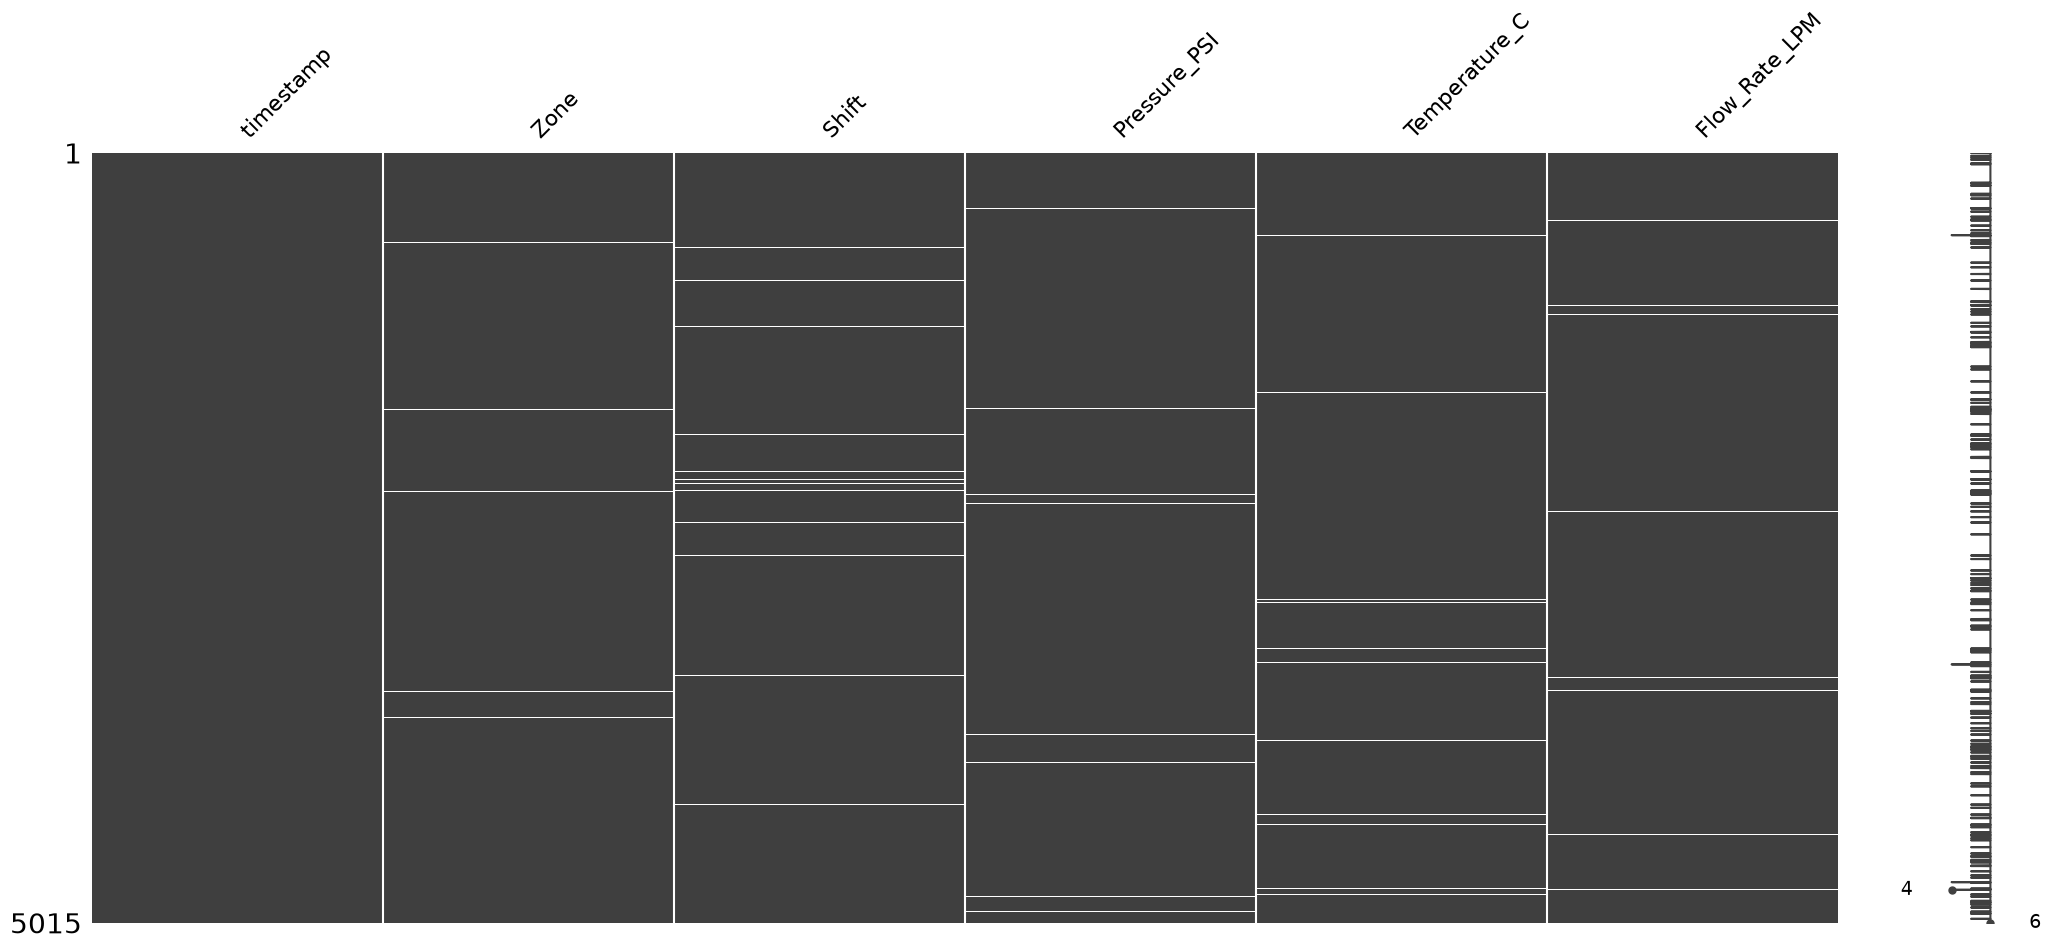

In [33]:
#Use missigno to display the location of missing data within the dataset
msno.matrix(df)

# DATA HEALTH REPORT - Issues identified in the dataframe
# Issue 1: Missing values


In [58]:
df.isna().sum()
# Calculate missing values, convert to DataFrame, and rename columns
missing_df = df.isna().sum().reset_index()
missing_df.columns = ['Column', 'Missing']
missing_df

,Column,Missing
0,timestamp,0
1,Zone,31
2,Shift,53
3,Pressure_PSI,40
4,Temperature_C,40
5,Flow_Rate_LPM,49


**From the findings above, only the timestamp column is complete, with no missing data, while the other columns have missing values: Zone (31 missing), Shift (53 missing), Pressure_PSI (40 missing), Temperature_C (40 missing), and Flow_Rate_LPM (49 missing)**

# Issue 2: Severe Sensor Outliers & Dropouts:


In [57]:
#Display the lowest, mean, and the maximum readings for temperature and pressure
print(f'Temperature and pressure summary: ')
df[['Temperature_C', 'Pressure_PSI']].describe()

Temperature and pressure summary: 


,Temperature_C,Pressure_PSI
count,4975.000000,4975.000000
mean,68.982323,255.254281
std,78.829078,845.810206
min,-273.150000,-50.000000
25%,55.023155,160.753008
50%,64.808608,200.294439
75%,74.527006,240.099173
max,1500.000000,15000.000000


**Pressure_PSI has a normal operating range of roughly 120 to 280 PSI. However, it contains severe sensor spikes up to 15000.0 PSI and 9999.0 PSI, as well as dropouts of -50.0 and exactly 0.0. These extreme readings are physically impossible in a standard process log and skew the mean (PSI instead of the actual PSI).**

**Temperature_C has a normal range of 45°C to 85 °C. However, it contains outlier spikes of 1500.0 °C and 800.0 °C, as well as dropouts of -273.15 °C (absolute zero) and exactly 0.0 °C.**

# Issue 3: Duplicate rows- *15 Duplicate entries were found*

In [50]:
# Calculate the total number of duplicate rows
total_duplicates = df.duplicated().sum()

# Conditional statement to check and print the result
if total_duplicates > 0:
    print(f"Total duplicates found in the dataframe: {total_duplicates}")
else:
    print("No duplicate rows found in the dataframe.")

Total duplicates found in the dataframe: 15


**Exact Duplicates & Date Typos:**

There are 15 exact duplicate rows that represent redundant logs. There is a single timestamp typo (2026-01-07 09:10:00) that lies six months before the rest of the log entries (which run from June 25 to July 1, 2026). This is a date typo where the month and day were swapped (it should be July 1st, 2026-07-01).

# Issue 4 — Inconsistent categorical labels for zones

In [54]:
# Get the count of unique labels in the Zone column
unique_count = df['Zone'].nunique()
# Display all the unique variations present in the Zone column
print(f"Number of distinct values found in 'Zone': {unique_count}")
df2 = df['Zone'].unique()
df2

Number of distinct values found in 'Zone': 15


<StringArray>
[  'Zone_South', 'Zone_Central',    'Zone_East',   'Zone_North',
    'Zone_West',   'ZONE_SOUTH',            nan,      'z_south',
      'z_north',  'Zone_South ',   'zone north',  ' South Zone',
  ' North Zone',   'ZONE-NORTH',  'Zone_North ',   'zone south']
Length: 16, dtype: str

**Zone contains 15 unique category variations due to casing and formatting inconsistencies (e.g., 'Zone_South', 'ZONE_SOUTH', 'z_south', ' South Zone', and 'zone south'). These represent the same physical area but are treated as separate regions by pandas. Shift contains missing values and represents a critical categorical feature. Furthermore, the shifts in the raw data do not match the logging times (noisy assignment).**

# 2. Cleaning Pipeline
**We construct a reusable function clean_ops_data(df) that handles the ingestion anomalies, standardizes categories, removes duplicates, filters outliers, and imputes missing values.**

In [93]:
import pandas as pd
import numpy as np

def clean_ops_data(raw_df):
    # Create a copy to avoid modifying the original dataframe
    df = raw_df.copy()
    
    # 1. TIMESTAMPS: Convert and fix the date typo
    
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    # Target the specific typo where month/day were swapped (2026-01-07 -> 2026-07-01)
    df.loc[df['timestamp'] == '2026-01-07 09:10:00', 'timestamp'] = pd.Timestamp('2026-07-01 09:10:00')
    
    # 2. DUPLICATES: Remove exact redundant log rows

    df = df.drop_duplicates()
    
    # 3. CATEGORICALS: Standardize 'Zone' and Fill 'Shift'
    
    if 'Zone' in df.columns:
        # Normalize strings and safely cast to string inside the lambda to handle NaNs
        df['Zone'] = df['Zone'].apply(lambda x: 
            'Zone_South' if 'south' in str(x).lower() else
            'Zone_North' if 'north' in str(x).lower() else
            'Zone_Central' if 'central' in str(x).lower() else
            'Zone_East' if 'east' in str(x).lower() else
            'Zone_West' if 'west' in str(x).lower() else 'Unknown_Zone'
        )
        
    if 'Shift' in df.columns:
        # Fill missing categorical shift values with 'Unknown' or the most frequent shift
        most_frequent_shift = df['Shift'].mode()[0] if not df['Shift'].mode().empty else 'Unknown'
        df['Shift'] = df['Shift'].fillna(most_frequent_shift)

    # 4. SENSOR OUTLIERS: Mask physically impossible values to NaN
    
    # Pressure normal range: ~120 to 280 PSI
    if 'Pressure_PSI' in df.columns:
        invalid_pressure = (df['Pressure_PSI'] < 120) | (df['Pressure_PSI'] > 280)
        df.loc[invalid_pressure, 'Pressure_PSI'] = np.nan
        
    # Temperature normal range: 45°C to 85°C
    if 'Temperature_C' in df.columns:
        invalid_temp = (df['Temperature_C'] < 45) | (df['Temperature_C'] > 85)
        df.loc[invalid_temp, 'Temperature_C'] = np.nan
        
    # Flow Rate: Check for negative values as dropouts
    if 'Flow_Rate_LPM' in df.columns:
        df.loc[df['Flow_Rate_LPM'] < 0, 'Flow_Rate_LPM'] = np.nan

    # 5. MISSING VALUES: Linear interpolation for sequential sensors
    
    # Sort by timestamp first to ensure sequential interpolation makes sense
    df = df.sort_values(by='timestamp').reset_index(drop=True)
    
    sensor_cols = ['Pressure_PSI', 'Temperature_C', 'Flow_Rate_LPM']
    for col in sensor_cols:
        if col in df.columns:
            # Interpolate sequential values, fill remaining edge NaNs with backward/forward fill
            df[col] = df[col].interpolate(method='linear').bfill().ffill()

    return df

# Verifying the outcome of data cleaning process

In [95]:
# View descriptive statistics to ensure sensor spikes are gone
cleaned_df[['Temperature_C', 'Pressure_PSI']].describe()

print("=== MISSING VALUES IN RAW DATA FRAME ===")
print(df.isna().sum())
print("\n=== MISSING VALUES IN CLEANED DATA FRAME ===")
print(cleaned_df.isna().sum())

print(f"Original DataFrame shape: {df.shape}")
print(f"Cleaned DataFrame shape:  {cleaned_df.shape}")
print(f"Rows removed (duplicates): {df.shape[0] - cleaned_df.shape[0]}")

print("=== RAW SENSOR LIMITS ===")
print(df[['Temperature_C', 'Pressure_PSI']].describe().loc[['min', 'max']])

print("\n=== CLEANED SENSOR LIMITS ===")
print(cleaned_df[['Temperature_C', 'Pressure_PSI']].describe().loc[['min', 'max']])

# Filter the dataframe to exclude 'Unknown_Zone'
cleaned_df = cleaned_df[cleaned_df['Zone'] != 'Unknown_Zone']

# Verify that 'Unknown_Zone' is completely gone
print("Remaining unique zones:")
print(cleaned_df['Zone'].unique())

print(f"\nNew dataframe shape: {cleaned_df.shape}")

print("=== UNIQUE ZONES IN RAW DATA ===")
print(f"Total Unique: {df['Zone'].nunique()}")
print(df['Zone'].unique())

print("\n=== UNIQUE ZONES IN CLEANED DATA ===")
print(f"Total Unique: {cleaned_df['Zone'].nunique()}")
print(cleaned_df['Zone'].unique())


=== MISSING VALUES IN RAW DATA FRAME ===
timestamp         0
Zone             31
Shift            53
Pressure_PSI     40
Temperature_C    40
Flow_Rate_LPM    49
dtype: int64

=== MISSING VALUES IN CLEANED DATA FRAME ===
timestamp        0
Zone             0
Shift            0
Pressure_PSI     0
Temperature_C    0
Flow_Rate_LPM    0
dtype: int64
Original DataFrame shape: (5015, 6)
Cleaned DataFrame shape:  (4969, 6)
Rows removed (duplicates): 46
=== RAW SENSOR LIMITS ===
     Temperature_C  Pressure_PSI
min        -273.15         -50.0
max        1500.00       15000.0

=== CLEANED SENSOR LIMITS ===
     Temperature_C  Pressure_PSI
min      45.004746    120.029631
max      84.995707    279.958604
Remaining unique zones:
<StringArray>
['Zone_West', 'Zone_Central', 'Zone_East', 'Zone_South', 'Zone_North']
Length: 5, dtype: str

New dataframe shape: (4969, 6)
=== UNIQUE ZONES IN RAW DATA ===
Total Unique: 15
<StringArray>
[  'Zone_South', 'Zone_Central',    'Zone_East',   'Zone_North',
    

# 3. Time-Series Analysis

**We resample the cleaned dataset to an hourly frequency and compute a 24-hour rolling average for the primary metric (Pressure_PSI).**

In [83]:
# 1. Set the timestamp column as the DataFrame index
# (Resampling requires a DatetimeIndex)
time_df = cleaned_df.set_index('timestamp')

# 2. Resample the data to an hourly frequency ('h')
# We use .mean() to aggregate all logs within each hour into a single average value
hourly_df = time_df[['Temperature_C', 'Pressure_PSI']].resample('h').mean()

# 3. Calculate the 24-hour rolling average
# window=24 means it will look back across the last 24 hourly rows
hourly_df['Temp_24h_Rolling_Avg'] = hourly_df['Temperature_C'].rolling(window=24, min_periods=1).mean()
hourly_df['Pressure_24h_Rolling_Avg'] = hourly_df['Pressure_PSI'].rolling(window=24, min_periods=1).mean()

# 4. Display the results
hourly_df[['Temperature_C', 'Temp_24h_Rolling_Avg', 'Pressure_PSI', 'Pressure_24h_Rolling_Avg']].head(30)

,Temperature_C,Temp_24h_Rolling_Avg,Pressure_PSI,Pressure_24h_Rolling_Avg
timestamp,,,,
2026-06-25 00:00:00,67.470742,67.470742,201.380407,201.380407
2026-06-25 01:00:00,64.581673,66.026208,196.280484,198.830446
2026-06-25 02:00:00,68.479328,66.843915,188.648468,195.436453
2026-06-25 03:00:00,63.402052,65.983449,198.603934,196.228323
2026-06-25 04:00:00,62.417240,65.270207,191.846007,195.351860
2026-06-25 05:00:00,65.865648,65.369447,220.896316,199.609269
2026-06-25 06:00:00,64.601827,65.259787,197.888934,199.363507
2026-06-25 07:00:00,66.901502,65.465002,218.125409,201.708745
2026-06-25 08:00:00,65.052915,65.419214,202.602072,201.808003


# 4. Aggregation

**We generate a summary table showing the Mean, Max, and Min values of the sensors for each Shift and Zone.**

In [84]:
# Group by both 'Shift' and 'Zone', then calculate mean, max, and min for the sensors
summary_table = cleaned_df.groupby(['Shift', 'Zone'])[['Temperature_C', 'Pressure_PSI', 'Flow_Rate_LPM']].agg(['mean', 'max', 'min'])

# Display the clean summary table
summary_table

Temperature_C                       Pressure_PSI  \
                                mean        max        min         mean   
Shift     Zone                                                            
Afternoon Zone_Central     65.075623  84.770133  45.004746   201.405958   
          Zone_East        64.539912  84.498265  45.148644   204.170357   
          Zone_North       64.330343  84.789882  45.025578   202.876382   
          Zone_South       64.495001  84.927914  45.009627   203.174186   
          Zone_West        64.110878  84.503430  45.052585   197.532897   
Morning   Zone_Central     65.182411  84.833824  45.016925   198.709258   
          Zone_East        66.021474  84.960378  45.328028   198.363036   
          Zone_North       64.494277  84.894647  45.144257   203.003523   
          Zone_South       65.003943  84.913456  45.495533   195.853635   
          Zone_West        63.953942  84.567169  45.235878   195.141460   
Night     Zone_Central     65.473837  84.656602  45.045145   198.635251   
          Zone_East        64.534570  84.992669  45.080282   201.750953   
          Zone_North       65.917001  84.995707  45.286978   200.343372   
          Zone_South       65.920901  84.986786  45.630976   200.898105   
          Zone_West        64.978405  84.813952  45.007021   199.020377   

                                               Flow_Rate_LPM               \
                               max         min          mean          max   
Shift     Zone                                                              
Afternoon Zone_Central  279.941700  120.216884   1009.206601  1395.586306   
          Zone_East     278.852932  120.863767    998.401277  1398.683481   
          Zone_North    279.854523  120.029631    995.414236  1398.293620   
          Zone_South    279.724389  120.218877    995.689314  1396.779247   
          Zone_West     279.607715  120.252707   1023.305850  1399.755865   
Morning   Zone_Central  279.892787  120.173923   1012.194877  1399.586163   
          Zone_East     279.953222  120.163568    993.333666  1398.093469   
          Zone_North    279.523489  120.795598   1005.218714  1399.614505   
          Zone_South    279.432081  121.281303    991.857545  1396.224193   
          Zone_West     279.898389  120.572407    988.297913  1398.527323   
Night     Zone_Central  279.919416  120.181036   1004.427682  1393.791731   
          Zone_East     279.890603  120.454745    991.211789  1398.438417   
          Zone_North    279.958604  120.695051   1002.654643  1399.482344   
          Zone_South    278.702857  121.767543    982.563351  1399.396874   
          Zone_West     279.613215  120.309106    997.907341  1398.416412   

                                    
                               min  
Shift     Zone                      
Afternoon Zone_Central  603.219689  
          Zone_East     601.609011  
          Zone_North    601.463958  
          Zone_South    615.176917  
          Zone_West     609.677670  
Morning   Zone_Central  600.823452  
          Zone_East     602.235507  
          Zone_North    600.007437  
          Zone_South    600.266374  
          Zone_West     600.229180  
Night     Zone_Central  600.685833  
          Zone_East     602.634583  
          Zone_North    601.092741  
          Zone_South    602.753999  
          Zone_West     603.712660

# 5. Visualization
**We generate a key plot comparing the Raw vs. Cleaned pressure trends over time to visualize the effect of our data wrangling pipeline.**

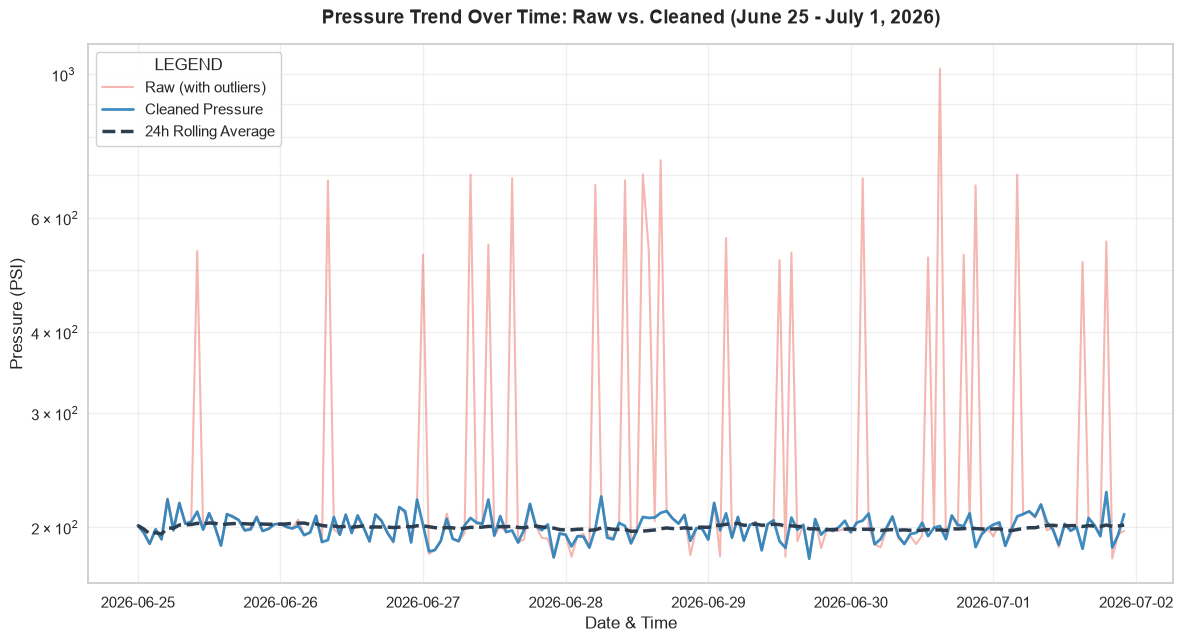

Chart saved successfully to pressure_comparison.png


In [92]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.close('all')

# 1. Force raw dataframe timestamp to datetime
raw_time_df = df.copy()
raw_time_df['timestamp'] = pd.to_datetime(raw_time_df['timestamp'])

# 2. FILTER OUT THE JANUARY TYPO FROM THE RAW DATA SO THE CHART ISN'T SQUISHED
# We only keep raw data from June 24, 2026 onwards
raw_time_df = raw_time_df[raw_time_df['timestamp'] >= '2026-06-24']

# 3. Create the hourly indexes now that the raw data is focused on the correct week
df_raw_hourly = raw_time_df.set_index('timestamp')[['Pressure_PSI']].resample('h').mean()
df_hourly = hourly_df 

# 4. Plotting
fig, ax = plt.subplots(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Plot Raw pressure (without the extreme timeline gap)
ax.plot(df_raw_hourly.index, df_raw_hourly['Pressure_PSI'], 
        color='#e74c3c', alpha=0.4, label='Raw (with outliers)', linewidth=1.5)

# Plot Cleaned pressure
ax.plot(df_hourly.index, df_hourly['Pressure_PSI'], 
        color='#2980b9', alpha=0.9, label='Cleaned Pressure', linewidth=2)

# Plot 24h rolling average
ax.plot(df_hourly.index, df_hourly['Pressure_24h_Rolling_Avg'], 
        color='#2c3e50', linestyle='--', label='24h Rolling Average', linewidth=2.5)

# 5. Formatting and Logarithmic Scaling
ax.set_title('Pressure Trend Over Time: Raw vs. Cleaned (June 25 - July 1, 2026)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date & Time', fontsize=12)
ax.set_ylabel('Pressure (PSI)', fontsize=12)

ax.set_yscale('log') 
ax.grid(True, which="both", ls="-", alpha=0.3)

# 6. Legend and Layout

# Move to the clear space and add a legend title
ax.legend(loc='upper left', title='LEGEND', frameon=True, facecolor='white', framealpha=0.9, fontsize=11, title_fontsize=12)

# Save and show the chart
chart_output_path = 'pressure_comparison.png'
plt.savefig(chart_output_path, dpi=300)
plt.show()

print(f"Chart saved successfully to {chart_output_path}")

In [96]:
import os
import matplotlib.pyplot as plt

# 1. Define the exact folder path where you want everything saved
target_folder = r"D:\EMTECH\PLP\Week 2\Data_Wrangling"


# 2. Save your Cleaned DataFrame as a fresh CSV file to this folder
csv_output_path = os.path.join(target_folder, "cleaned_sensor_readings.csv")
cleaned_df.to_csv(csv_output_path, index=False)
print(f"Cleaned data CSV saved to: {csv_output_path}")

# 3. Save your trend chart image to this folder
chart_output_path = os.path.join(target_folder, "pressure_comparison.png")
fig.savefig(chart_output_path, dpi=300)
print(f"Chart image saved to: {chart_output_path}")

Cleaned data CSV saved to: D:\EMTECH\PLP\Week 2\Data_Wrangling\cleaned_sensor_readings.csv
Chart image saved to: D:\EMTECH\PLP\Week 2\Data_Wrangling\pressure_comparison.png
